# 04 · Compositional analysis — LUAD vs LUSC

**Phase 4 of the project** ([PROJECT_PLAN.md](../PROJECT_PLAN.md)).

**Question.** Across the LuCA cohort, does the *cell-type composition* of a
tumour distinguish the two major non-small-cell lung cancer histologies —
adenocarcinoma (LUAD) and squamous-cell carcinoma (LUSC) — and which
cell-type proportions carry that signal?

**Approach.**

1. Collapse notebook 03's per-cell annotation to a **per-patient composition
   vector**: the nine cell-type proportions for each patient.
2. Train classifiers (gradient-boosted trees, logistic regression, and a
   dummy baseline) to predict histology from those nine proportions.
3. Evaluate with **leave-one-study-out cross-validation** — see the note in
   section 4 on why the cross-validation groups must be *studies*, not
   patients.
4. Identify which cell types drive the prediction (permutation importance),
   and run a **label-shuffle negative control** to check the signal is real.

**A note on scale — read this first.** This is a *small* patient cohort.
Requiring at least 200 annotated cells per patient for a stable composition
vector leaves roughly 70 patients, and the two classes are imbalanced
(~70 % LUAD). So this notebook is a proof-of-method, not a clinical claim:
it demonstrates a correct compositional-analysis and grouped-CV workflow,
and reports its own uncertainty honestly. The metrics here should be read
as "is there a detectable signal," not "here is a validated diagnostic."

**Inputs**: `data/processed/luca_annotated.h5ad` (from notebook 03 — needs
`obs["cell_type_pred"]`, `obs["donor_id"]`, `obs["disease"]`, `obs["study"]`).
Opened in **backed mode**: only `obs` is read, the expression matrix stays
on disk.

**Outputs**:
- `data/processed/patient_composition.csv` — the per-patient feature table
- `figures/composition_by_histology.png`, `figures/roc_curves.png`,
  `figures/confusion_matrix_histology.png`, `figures/feature_importance.png`,
  `figures/label_shuffle_null.png`
- `figures/composition_metrics.csv` (tracked in git)

**Time budget**: ~1–2 min — everything here runs on a ~70 × 9 table.

## 1. Setup

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repo root. Launch Jupyter from inside the repo (standard
# workflow); if launching from elsewhere, set the REPO_ROOT env variable.
def _find_repo_root():
    env = os.environ.get("REPO_ROOT")
    if env and (Path(env) / "src" / "subsample.py").exists():
        return Path(env).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "subsample.py").exists():
            return p.resolve()
    raise RuntimeError(
        "Repo root not found. Launch Jupyter from inside the repository, "
        "or set the REPO_ROOT environment variable."
    )

ROOT = _find_repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


def relpath(p):
    """Path relative to the repo root - keeps printed paths portable."""
    p = Path(p)
    try:
        return p.relative_to(ROOT)
    except ValueError:
        return p.name


FIG_DIR = ROOT / "figures"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 0
plt.rcParams["figure.dpi"] = 100
print(f"repo root: {ROOT.name}/")
print(f"anndata {ad.__version__}")

repo root: scrnaseq-tumor-microenvironment/
anndata 0.12.14


## 2. Build the patient table

We need one row per patient, not per cell. LuCA's `donor_id` is the patient
identifier; each donor carries a single `disease` and a single `study`
(verified by the assertions below).

Two filters define the analysis cohort:

- **Histology** — keep only `lung adenocarcinoma` (LUAD) and
  `squamous cell lung carcinoma` (LUSC). Normal tissue, COPD, and the generic
  `non-small cell lung carcinoma` label are dropped: the question is
  specifically LUAD-vs-LUSC.
- **Minimum cells per patient** — a composition vector built from very few
  cells is noisy, especially for rare lineages. We require `MIN_CELLS`
  annotated cells per patient. 200 is a deliberate trade-off: lower it to
  retain more patients (at noisier proportions), raise it for cleaner
  vectors (at a smaller cohort). It is a single constant here so you can
  test the sensitivity.

In [2]:
# Backed mode: read obs only, leave the 1.2 GB expression matrix on disk.
ann_path = PROC_DIR / "luca_annotated.h5ad"
adata = ad.read_h5ad(ann_path, backed="r")
obs = adata.obs.copy()
print(f"cells: {len(obs):,} | donors: {obs['donor_id'].nunique()} | "
      f"studies: {obs['study'].nunique()}")

LUAD = "lung adenocarcinoma"
LUSC = "squamous cell lung carcinoma"
MIN_CELLS = 200          # min annotated cells per patient

# One row per donor. Each donor must have a single disease and single study.
by_donor = obs.groupby("donor_id", observed=True)
assert (by_donor["disease"].nunique() == 1).all(), "a donor spans >1 disease"
assert (by_donor["study"].nunique() == 1).all(), "a donor spans >1 study"

donor = by_donor.agg(
    disease=("disease", "first"),
    study=("study", "first"),
    n_cells=("disease", "size"),
)
donor["histology"] = donor["disease"].map({LUAD: "LUAD", LUSC: "LUSC"})

patients = donor[donor["histology"].notna() & (donor["n_cells"] >= MIN_CELLS)].copy()
print(f"\nAnalysis cohort: {len(patients)} patients "
      f"(>= {MIN_CELLS} cells, LUAD or LUSC)")
print(patients["histology"].value_counts().to_string())
print(f"\nstudies represented: {patients['study'].nunique()}  "
      f"(these are the cross-validation folds)")
print("patients per study:")
print(patients.groupby("study", observed=True)["histology"]
      .value_counts().unstack(fill_value=0).to_string())

cells: 92,013 | donors: 298 | studies: 19

Analysis cohort: 71 patients (>= 200 cells, LUAD or LUSC)
histology
LUAD    50
LUSC    21

studies represented: 10  (these are the cross-validation folds)
patients per study:
histology                  LUAD  LUSC
study                                
Goveia_Carmeliet_2020         3     4
Guo_Zhang_2018                7     3
He_Fan_2021                   5     0
Lambrechts_Thienpont_2018     3     3
Laughney_Massague_2020        7     0
Maier_Merad_2020              6     2
Maynard_Bivona_2020           6     1
UKIM-V                        2     1
Wu_Zhou_2021                  6     6
Zilionis_Klein_2019           5     1


## 3. Cell-type composition features

For each patient, the feature vector is the **fraction of that patient's
cells assigned to each of the nine lineages** — a point on the 9-part
simplex (the nine proportions sum to 1).

A caveat worth stating: compositional data is not, strictly, Euclidean — the
sum-to-one constraint induces negative correlations between proportions, and
a fully rigorous treatment would use a log-ratio transform. For nine coarse
lineages fed mostly to tree models that is a second-order concern, so we keep
raw proportions for interpretability and flag the point here rather than
silently ignoring it.

In [3]:
# Per-patient cell-type proportions -> (patient x 9 lineage) matrix.
cohort_cells = obs[obs["donor_id"].isin(patients.index)]
counts = (cohort_cells
          .groupby(["donor_id", "cell_type_pred"], observed=True)
          .size()
          .unstack(fill_value=0))
prop = counts.div(counts.sum(axis=1), axis=0)
prop = prop.loc[patients.index]              # align row order to `patients`
LINEAGES = list(prop.columns)

# Assemble the modelling table.
feature_table = patients[["histology", "study", "n_cells"]].join(prop)
print(f"feature table: {feature_table.shape[0]} patients x "
      f"{len(LINEAGES)} composition features")
print(f"lineages: {LINEAGES}")
print()
print("mean composition by histology:")
print((feature_table.groupby("histology")[LINEAGES].mean() * 100)
      .round(1).to_string())

feature table: 71 patients x 9 composition features
lineages: ['B cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast cell', 'Myeloid', 'NK cell', 'Plasma cell', 'T cell']

mean composition by histology:
           B cell  Endothelial  Epithelial  Fibroblast  Mast cell  Myeloid  NK cell  Plasma cell  T cell
histology                                                                                               
LUAD          3.9          3.9        14.0         2.1        1.4     31.9      6.7          3.0    33.1
LUSC          1.6         11.2        29.0         3.8        0.8     25.0      3.1          3.3    22.2


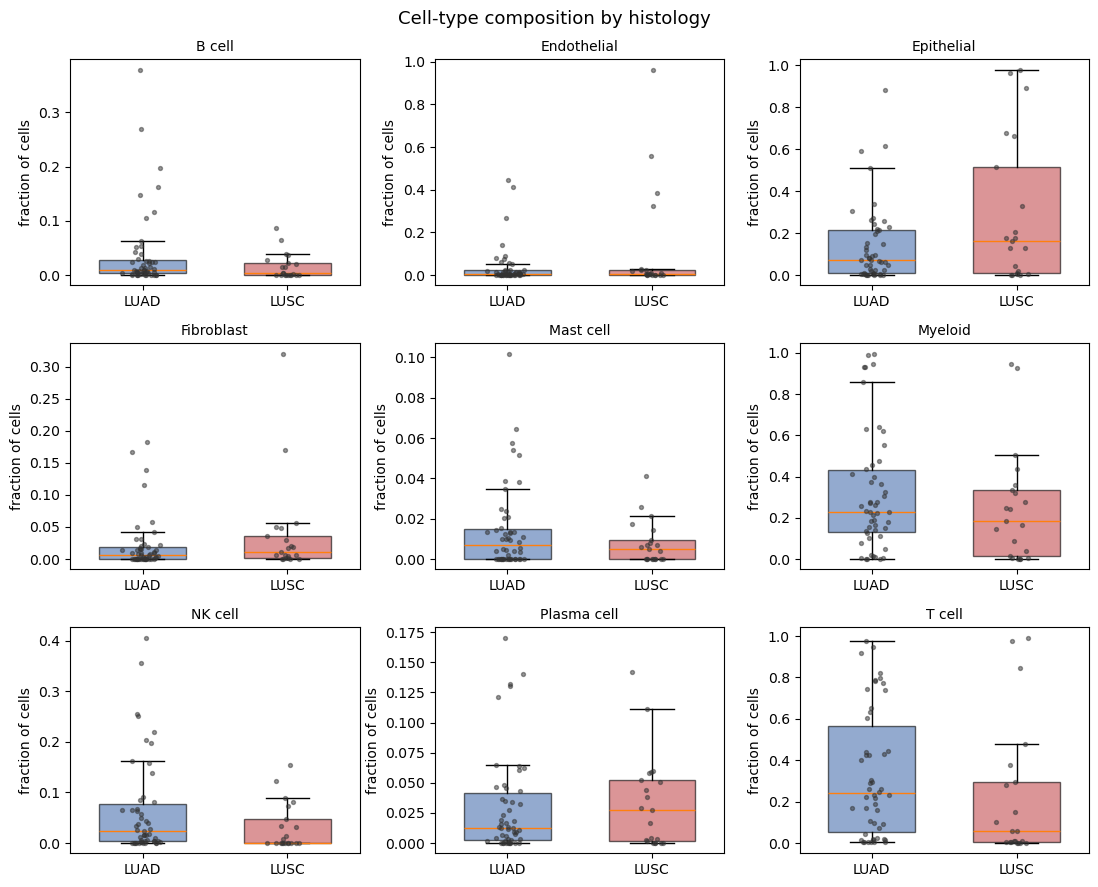

In [4]:
# Composition of each lineage, split by histology.
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for ax, lin in zip(axes.flat, LINEAGES):
    data = [feature_table.loc[feature_table["histology"] == h, lin].values
            for h in ["LUAD", "LUSC"]]
    bp = ax.boxplot(data, widths=0.6,
                    patch_artist=True, showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["LUAD", "LUSC"])
    for patch, c in zip(bp["boxes"], ["#4C72B0", "#C44E52"]):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    for i, d in enumerate(data):                       # jittered points
        x = np.random.default_rng(0).normal(i + 1, 0.06, size=len(d))
        ax.scatter(x, d, s=8, c="#333", alpha=0.5, zorder=3)
    ax.set_title(lin, fontsize=10)
    ax.set_ylabel("fraction of cells")
fig.suptitle("Cell-type composition by histology", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "composition_by_histology.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 4. LUAD vs LUSC classifier — leave-one-study-out CV

**Why the CV folds are studies, not patients.** The LuCA atlas pools 19
studies, and study-of-origin is the dominant nuisance signal (different
labs, protocols, instruments). A random or leave-one-patient-out split would
let the model learn "this looks like study X" and leak that into the score,
because the same study's other patients sit in both train and test. Holding
out a *whole study* at a time forces the model to generalise across cohorts —
a far more honest estimate of whether composition really predicts histology.

We use `cross_val_predict` to collect an **out-of-fold prediction for every
patient**, then score once on the pooled predictions. Pooling (rather than
averaging a per-fold AUROC) is what makes the small folds usable: some
studies contribute only LUAD patients, and AUROC is undefined on a
single-class fold.

Three models, so the headline number has context:

- **Gradient-boosted trees** — the primary model (shallow trees, small
  cohort).
- **Logistic regression** — a linear baseline; at this sample size a linear
  model is often just as good and worth seeing.
- **Dummy (stratified)** — predicts by class frequency; the floor any real
  model must clear.

In [5]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             accuracy_score)

X = feature_table[LINEAGES].to_numpy()
y = (feature_table["histology"] == "LUSC").astype(int).to_numpy()  # LUSC = 1
groups = feature_table["study"].to_numpy()
logo = LeaveOneGroupOut()
print(f"{X.shape[0]} patients x {X.shape[1]} features | "
      f"{len(np.unique(groups))} studies = {len(np.unique(groups))} CV folds")
print(f"class balance: LUAD={int((y==0).sum())}  LUSC={int((y==1).sum())}")

models = {
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.05,
        random_state=RANDOM_STATE),
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000,
                           random_state=RANDOM_STATE)),
    "Dummy (stratified)": DummyClassifier(
        strategy="stratified", random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    oof = cross_val_predict(model, X, y, groups=groups, cv=logo,
                            method="predict_proba")[:, 1]
    pred = (oof >= 0.5).astype(int)
    results[name] = {
        "oof_proba": oof,
        "auroc": roc_auc_score(y, oof),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "accuracy": accuracy_score(y, pred),
    }

summary = pd.DataFrame(results).T[["auroc", "balanced_accuracy", "accuracy"]]
print()
print(summary.round(3).to_string())

71 patients x 9 features | 10 studies = 10 CV folds
class balance: LUAD=50  LUSC=21

                       auroc balanced_accuracy  accuracy
GradientBoosting    0.481905          0.589048  0.732394
LogisticRegression  0.434286          0.509048  0.619718
Dummy (stratified)  0.437619          0.437619  0.577465


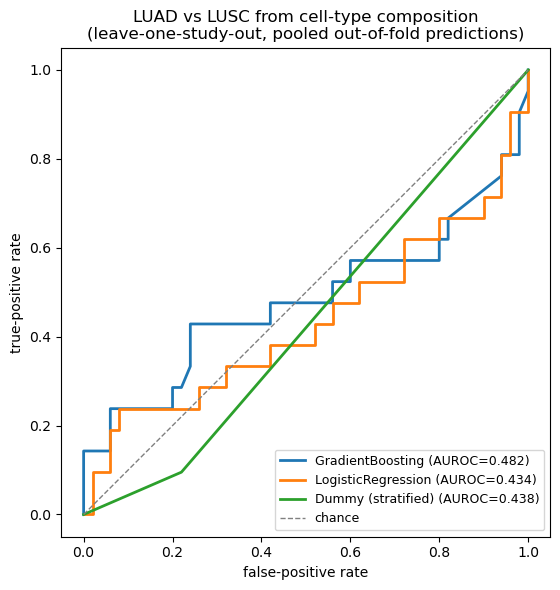

In [6]:
# ROC curves from the pooled out-of-fold predictions.
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y, res["oof_proba"])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUROC={res['auroc']:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="chance")
ax.set_xlabel("false-positive rate")
ax.set_ylabel("true-positive rate")
ax.set_title("LUAD vs LUSC from cell-type composition\n"
             "(leave-one-study-out, pooled out-of-fold predictions)")
ax.legend(loc="lower right", fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

--- GradientBoosting: out-of-fold classification report ---
              precision    recall  f1-score   support

        LUAD      0.746     0.940     0.832        50
        LUSC      0.625     0.238     0.345        21

    accuracy                          0.732        71
   macro avg      0.686     0.589     0.588        71
weighted avg      0.710     0.732     0.688        71



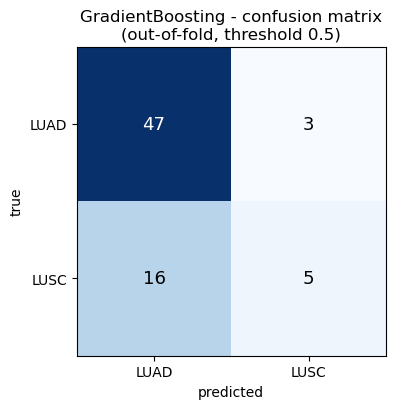

In [7]:
# Confusion matrix + per-class report for the primary model.
from sklearn.metrics import confusion_matrix, classification_report

PRIMARY = "GradientBoosting"
oof = results[PRIMARY]["oof_proba"]
pred = (oof >= 0.5).astype(int)
cm = confusion_matrix(y, pred)

print(f"--- {PRIMARY}: out-of-fold classification report ---")
print(classification_report(y, pred, target_names=["LUAD", "LUSC"],
                            digits=3))

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["LUAD", "LUSC"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["LUAD", "LUSC"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{PRIMARY} - confusion matrix\n(out-of-fold, threshold 0.5)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix_histology.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5. Which cell types drive the prediction?

Permutation importance: shuffle one feature column, measure how much the
AUROC drops. A large drop means the model leaned on that lineage.

Caveat — this is computed on a model fit to the **full table** (no held-out
fold), so it describes *what this fitted model used*, not an independently
validated effect. It answers "which lineages carry the signal," read
alongside the composition boxplots in section 3, not as a standalone result.

Permutation importance (drop in AUROC when the lineage is shuffled):
             importance      sd
lineage                        
Mast cell        0.0006  0.0007
Fibroblast       0.0057  0.0029
NK cell          0.0060  0.0023
B cell           0.0074  0.0041
Endothelial      0.0077  0.0038
Epithelial       0.0079  0.0065
Myeloid          0.0161  0.0072
Plasma cell      0.0195  0.0057
T cell           0.1556  0.0291


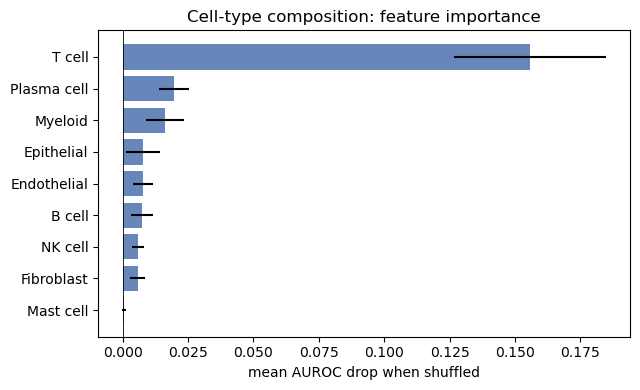

In [8]:
from sklearn.inspection import permutation_importance

imp_model = GradientBoostingClassifier(
    n_estimators=100, max_depth=2, learning_rate=0.05,
    random_state=RANDOM_STATE).fit(X, y)
pi = permutation_importance(
    imp_model, X, y, scoring="roc_auc",
    n_repeats=50, random_state=RANDOM_STATE)

imp = (pd.DataFrame({"lineage": LINEAGES,
                     "importance": pi.importances_mean,
                     "sd": pi.importances_std})
       .sort_values("importance"))
print("Permutation importance (drop in AUROC when the lineage is shuffled):")
print(imp.set_index("lineage").round(4).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.barh(imp["lineage"], imp["importance"], xerr=imp["sd"],
        color="#4C72B0", alpha=0.85)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("mean AUROC drop when shuffled")
ax.set_title("Cell-type composition: feature importance")
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Negative control — label permutation

The honest question for a small cohort: *could this AUROC arise by chance?*
We shuffle the histology labels and rerun the entire leave-one-study-out
pipeline many times. With the labels randomised the model should score near
0.5; the spread of those shuffled scores is the null distribution.

The empirical p-value is the fraction of shuffles that match or beat the
real AUROC (with the usual +1 correction). If the real score sits clearly
outside the null cloud, the composition signal is real.

real AUROC (GradientBoosting):       0.482
shuffled-label AUROC:       0.484 +/- 0.091  (n=100)
empirical p-value:          0.535


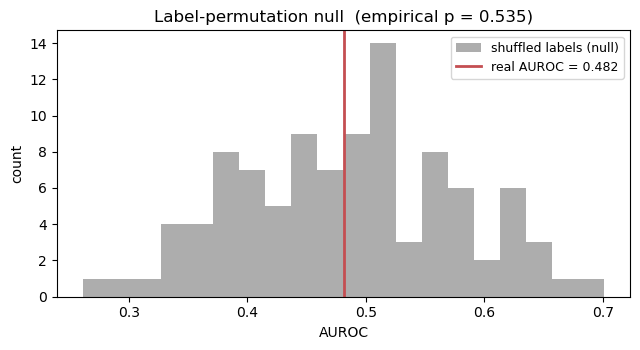

In [9]:
N_PERM = 100
rng = np.random.default_rng(RANDOM_STATE)
real_auroc = results[PRIMARY]["auroc"]

null_aurocs = []
for _ in range(N_PERM):
    y_perm = rng.permutation(y)
    oof_perm = cross_val_predict(
        GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                   learning_rate=0.05,
                                   random_state=RANDOM_STATE),
        X, y_perm, groups=groups, cv=logo, method="predict_proba")[:, 1]
    null_aurocs.append(roc_auc_score(y_perm, oof_perm))
null_aurocs = np.array(null_aurocs)

p_emp = (1 + int((null_aurocs >= real_auroc).sum())) / (1 + N_PERM)
print(f"real AUROC ({PRIMARY}):       {real_auroc:.3f}")
print(f"shuffled-label AUROC:       {null_aurocs.mean():.3f} "
      f"+/- {null_aurocs.std():.3f}  (n={N_PERM})")
print(f"empirical p-value:          {p_emp:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(null_aurocs, bins=20, color="#999", alpha=0.8,
        label="shuffled labels (null)")
ax.axvline(real_auroc, color="#C44E52", lw=2,
           label=f"real AUROC = {real_auroc:.3f}")
ax.set_xlabel("AUROC")
ax.set_ylabel("count")
ax.set_title(f"Label-permutation null  (empirical p = {p_emp:.3f})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "label_shuffle_null.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Companion — tumour vs normal composition (descriptive only)

An obvious follow-up: does cell-type composition separate **tumour** tissue
from **normal lung**? Descriptively, yes — and we show that below. But we
deliberately stop at *descriptive* and do **not** build a classifier here,
for a specific and important reason.

**The confound.** In this LuCA subsample, every normal-tissue donor comes
from a healthy-lung or fibrosis atlas (Habermann, Reyfman, Travaglini, …) and
every tumour donor comes from a cancer study. **No study contains both.**
Tumour/normal status is therefore perfectly aliased with study-of-origin. A
leave-one-study-out classifier would post a high AUROC, but that number would
be uninterpretable: it could not separate "detected tumour immune
infiltration" from "detected the batch signature of a cancer-study protocol
versus a lung-atlas protocol." The cell below prints the study × group table
so the confound is explicit.

So this section reports the composition *contrast* — which is real and
biologically sensible — while being honest that, in this dataset, it cannot
be promoted to a validated predictive claim.

In [10]:
# Tumour vs normal donor table (reuses `donor` and MIN_CELLS from section 2).
TUMOUR_DISEASES = {"lung adenocarcinoma", "squamous cell lung carcinoma",
                   "non-small cell lung carcinoma"}
donor["tn_group"] = np.where(
    donor["disease"] == "normal", "Normal",
    np.where(donor["disease"].isin(TUMOUR_DISEASES), "Tumour", None))

tn = donor[donor["tn_group"].notna() & (donor["n_cells"] >= MIN_CELLS)].copy()
print(f"tumour/normal cohort: {len(tn)} donors (>= {MIN_CELLS} cells)")
print(tn["tn_group"].value_counts().to_string())

# The confound, made explicit: study x group.
confound = (tn.groupby("study", observed=True)["tn_group"]
            .value_counts().unstack(fill_value=0))
for c in ["Tumour", "Normal"]:
    if c not in confound:
        confound[c] = 0
n_both = int(((confound["Tumour"] > 0) & (confound["Normal"] > 0)).sum())
print("\nstudy x group  (each study is entirely tumour or entirely normal):")
print(confound[["Tumour", "Normal"]].to_string())
print(f"\nstudies containing BOTH tumour and normal donors: "
      f"{n_both} / {len(confound)}")
print("=> study and tumour/normal label are perfectly confounded; no "
      "cross-validated classifier is built (see the markdown above).")

tumour/normal cohort: 124 donors (>= 200 cells)
tn_group
Tumour    83
Normal    41

study x group  (each study is entirely tumour or entirely normal):
tn_group                   Tumour  Normal
study                                    
Adams_Kaminski_2020             0       5
Chen_Zhang_2020                 8       0
Goveia_Carmeliet_2020           7       0
Guo_Zhang_2018                 10       0
Habermann_Kropski_2020          0       8
He_Fan_2021                     5       0
Lambrechts_Thienpont_2018       8       0
Laughney_Massague_2020          7       0
Madissoon_Meyer_2020            0       5
Maier_Merad_2020                8       0
Maynard_Bivona_2020             7       0
Mayr_Schiller_2020              0       8
Reyfman_Misharin_2018           0       8
Travaglini_Krasnow_2020         0       3
UKIM-V                          3       0
Vieira_Teichmann_2019           0       4
Wu_Zhou_2021                   14       0
Zilionis_Klein_2019             6       0

studies 

In [11]:
# Composition vectors for the tumour/normal cohort.
tn_cells = obs[obs["donor_id"].isin(tn.index)]
tn_counts = (tn_cells.groupby(["donor_id", "cell_type_pred"], observed=True)
             .size().unstack(fill_value=0))
tn_prop = tn_counts.div(tn_counts.sum(axis=1), axis=0).loc[tn.index]
tn_table = tn[["tn_group", "study", "n_cells"]].join(tn_prop)

mean_comp = tn_table.groupby("tn_group")[LINEAGES].mean() * 100
mean_comp.loc["difference"] = mean_comp.loc["Tumour"] - mean_comp.loc["Normal"]
print("mean cell-type composition (%) — tumour vs normal:")
print(mean_comp.round(1).T.to_string())

mean cell-type composition (%) — tumour vs normal:
tn_group     Normal  Tumour  difference
B cell          0.8     4.0         3.2
Endothelial     7.5     5.3        -2.2
Epithelial     33.7    18.4       -15.4
Fibroblast      3.4     2.5        -0.9
Mast cell       2.6     1.3        -1.3
Myeloid        38.2    29.3        -8.9
NK cell         5.5     5.2        -0.4
Plasma cell     1.1     3.7         2.5
T cell          7.2    30.4        23.2


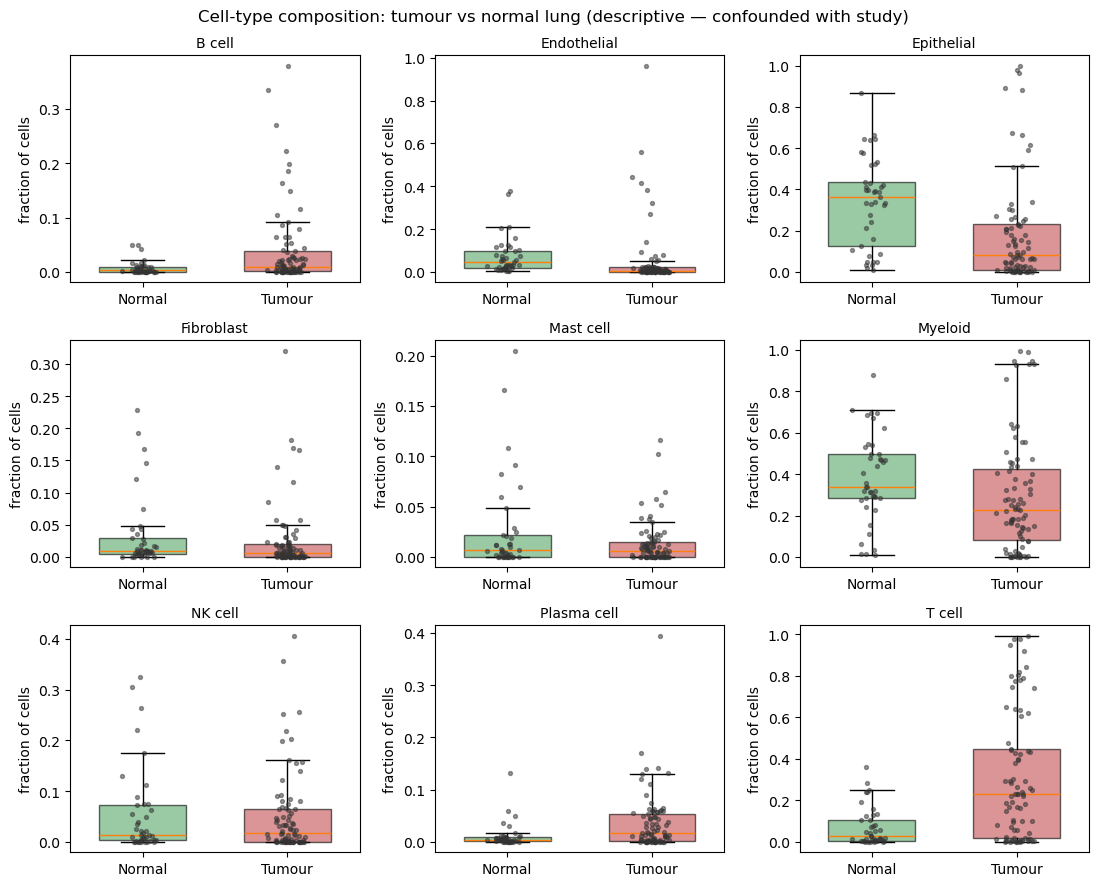

In [12]:
# Composition of each lineage, tumour vs normal (descriptive).
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for ax, lin in zip(axes.flat, LINEAGES):
    data = [tn_table.loc[tn_table["tn_group"] == g, lin].values
            for g in ["Normal", "Tumour"]]
    bp = ax.boxplot(data, widths=0.6,
                    patch_artist=True, showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Normal", "Tumour"])
    for patch, c in zip(bp["boxes"], ["#55A868", "#C44E52"]):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    for i, d in enumerate(data):
        x = np.random.default_rng(0).normal(i + 1, 0.06, size=len(d))
        ax.scatter(x, d, s=8, c="#333", alpha=0.5, zorder=3)
    ax.set_title(lin, fontsize=10)
    ax.set_ylabel("fraction of cells")
fig.suptitle("Cell-type composition: tumour vs normal lung "
             "(descriptive — confounded with study)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "composition_tumor_vs_normal.png", dpi=150,
            bbox_inches="tight")
plt.show()

The contrast is large and in the expected direction — normal lung is
dominated by epithelial and endothelial cells, tumour tissue is far more
immune-infiltrated (myeloid and T cells). That is consistent with known
tumour biology. But because the comparison is perfectly confounded with
study, the honest statement is *composition differs between these two sets
of samples*, not *composition predicts tumour status*. Separating biology
from batch would need a dataset where tumour and matched normal-adjacent
tissue come from the same study and protocol.

## 8. Save outputs

In [13]:
# Per-patient feature tables - the modelling inputs, kept for reproducibility.
feat_path = PROC_DIR / "patient_composition.csv"
feature_table.to_csv(feat_path)
print(f"Wrote {relpath(feat_path)}  ({feature_table.shape[0]} LUAD/LUSC patients)")

tn_path = PROC_DIR / "patient_composition_tumor_normal.csv"
tn_table.to_csv(tn_path)
print(f"Wrote {relpath(tn_path)}  ({tn_table.shape[0]} tumour/normal donors)")

# Headline metrics (tracked in git).
metrics = pd.DataFrame({
    "metric": ["n_patients", "n_luad", "n_lusc", "n_studies",
               "auroc_gradientboosting", "auroc_logreg", "auroc_dummy",
               "balanced_accuracy_primary", "null_auroc_mean", "perm_p_value",
               "tumor_normal_studies_with_both"],
    "value": [
        int(X.shape[0]), int((y == 0).sum()), int((y == 1).sum()),
        int(len(np.unique(groups))),
        round(results["GradientBoosting"]["auroc"], 4),
        round(results["LogisticRegression"]["auroc"], 4),
        round(results["Dummy (stratified)"]["auroc"], 4),
        round(results[PRIMARY]["balanced_accuracy"], 4),
        round(float(null_aurocs.mean()), 4),
        round(float(p_emp), 4),
        int(n_both),
    ],
})
metrics_path = FIG_DIR / "composition_metrics.csv"
metrics.to_csv(metrics_path, index=False)
print(f"Wrote {relpath(metrics_path)}")
print()
print(metrics.to_string(index=False))

Wrote data\processed\patient_composition.csv  (71 LUAD/LUSC patients)
Wrote data\processed\patient_composition_tumor_normal.csv  (124 tumour/normal donors)
Wrote figures\composition_metrics.csv

                        metric   value
                    n_patients 71.0000
                        n_luad 50.0000
                        n_lusc 21.0000
                     n_studies 10.0000
        auroc_gradientboosting  0.4819
                  auroc_logreg  0.4343
                   auroc_dummy  0.4376
     balanced_accuracy_primary  0.5890
               null_auroc_mean  0.4842
                  perm_p_value  0.5347
tumor_normal_studies_with_both  0.0000


## Summary — Phase 4 complete

- Collapsed notebook 03's per-cell annotation into a per-patient
  composition table: nine cell-type proportions per patient.
- **LUAD vs LUSC.** Trained gradient-boosted-tree, logistic-regression, and
  dummy classifiers; evaluated with leave-one-study-out cross-validation and
  pooled out-of-fold predictions; ranked drivers with permutation importance;
  ran a 100-iteration label-permutation negative control.
- **Tumour vs normal (companion).** Reported the composition contrast
  descriptively, and documented that tumour/normal status is perfectly
  confounded with study-of-origin in LuCA — so no classifier is built.

**How to read the LUAD-vs-LUSC result.** The honest headline is the gap
between the real AUROC, the dummy baseline, and the label-shuffle null. If
the real score sits clearly above the null cloud (low empirical p),
composition carries a genuine signal across cohorts; if it overlaps the null,
the signal is not detectable at this sample size — a legitimate, reportable
finding either way.

**Limitations.** Small LUAD/LUSC cohort (~70 patients) with class imbalance;
a single held-out study can be all-LUAD; permutation importance is computed
in-sample; proportions are treated as plain features despite the simplex
constraint; the tumour/normal contrast is confounded with study and is
therefore descriptive only. These are stated so the repo is read as a sound
*method* demonstration.

**Possible extensions.** Lower `MIN_CELLS` to trade vector quality for cohort
size and check robustness; add per-cell-type interferon or proliferation
signature scores as extra features; or pursue the within-LUAD never-smoker
vs smoker comparison sketched in PROJECT_PLAN.md.

This is the last analysis notebook. What remains (PROJECT_PLAN.md phase 5) is
writing: fold the results — the LUAD/LUSC outcome, the driver lineages, the
negative control, and the tumour/normal confound — into the README's Results
section, and a final pass over figures and code.